In [ ]:
!pip install xgboost imbalanced-learn pandas scikit-learn pennylane

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Classical XGBoost Model

Preparing dataset...
Original Dataset Profiles:
 - Low/Moderate Risk samples in training: 3523
 - High Risk samples in training: 1737
 - Calculated scale_pos_weight: 2.0282

Training XGBoost Classifier...
Training complete!

Running predictions...

================ CLASSICAL XGBOOST (NO SMOTE) ================
Accuracy:  0.7584
Precision: 0.6184
Recall:    0.6982
F1-Score:  0.6558

Detailed Classification Report:
              precision    recall  f1-score   support

Low/Mod Risk       0.84      0.79      0.81       882
   High Risk       0.62      0.70      0.66       434

    accuracy                           0.76      1316
   macro avg       0.73      0.74      0.73      1316
weighted avg       0.77      0.76      0.76      1316


Confusion matrix visualization saved successfully as 'xgb_confusion_matrix.png'!


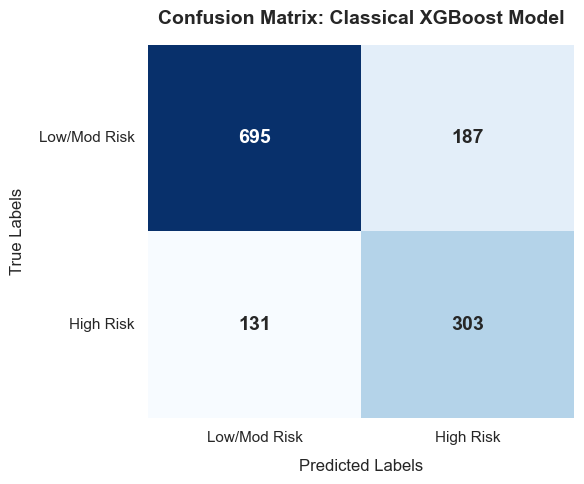

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb

# ---------------------------------------------------------
# 1. Load and Preprocess Data (No SMOTE)
# ---------------------------------------------------------
print("Preparing dataset...")
df = pd.read_csv('modified-shuffled.csv')

# Dynamic environmental drivers ONLY (Data leakage removed)
features_to_use = [
    'wave_height', 'wave_period', 'wave_direction', 
    'precipitation', 'wind_speed', 'tidal_height_m'
]
X = df[features_to_use].values
y = df['erosion_risk'].apply(lambda x: 1 if x == 'High' else 0).values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Calculate the exact class imbalance ratio directly from your dataset
num_low_mod = np.sum(y_train == 0)
num_high = np.sum(y_train == 1)
imbalance_ratio = num_low_mod / num_high

print(f"Original Dataset Profiles:")
print(f" - Low/Moderate Risk samples in training: {num_low_mod}")
print(f" - High Risk samples in training: {num_high}")
print(f" - Calculated scale_pos_weight: {imbalance_ratio:.4f}")

# ---------------------------------------------------------
# 2. Initialize and Train XGBoost Classifier
# ---------------------------------------------------------
print("\nTraining XGBoost Classifier...")

xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=imbalance_ratio,  # <-- Handles imbalance directly on your raw data
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)
print("Training complete!")

# ---------------------------------------------------------
# 3. Predictions and Evaluation
# ---------------------------------------------------------
print("\nRunning predictions...")
y_pred = xgb_model.predict(X_test_scaled)

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n================ CLASSICAL XGBOOST (NO SMOTE) ================")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("==============================================================")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low/Mod Risk', 'High Risk']))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# 5. Generate and Plot Confusion Matrix
# ---------------------------------------------------------
# Compute the 2x2 confusion matrix array
cm = confusion_matrix(y_test, y_pred)

# Set up the plotting environment
plt.figure(figsize=(6, 5))
sns.set_theme(style="white")

# Plot using a seaborn heatmap
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Low/Mod Risk', 'High Risk'], 
    yticklabels=['Low/Mod Risk', 'High Risk'],
    annot_kws={"size": 14, "weight": "bold"}
)

# Formatting labels and titles
plt.title('Confusion Matrix: Classical XGBoost Model', fontsize=14, pad=15, weight='bold')
plt.xlabel('Predicted Labels', fontsize=12, labelpad=10)
plt.ylabel('True Labels', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()

# Save the matrix image for your report/presentation
plt.savefig('xgb_confusion_matrix.png', dpi=300)
print("\nConfusion matrix visualization saved successfully as 'xgb_confusion_matrix.png'!")

# Display the plot
plt.show()

# Quantum Model

Preparing dataset for Cost-Sensitive PennyLane...
Safety Multiplier for High Risk Class: 2.0282

Starting Quantum Training with Safety-Weighted Cost Function...
Epoch 01 | Safety Loss: 1.0512 | Est. Train Acc: 0.74
Epoch 02 | Safety Loss: 1.1065 | Est. Train Acc: 0.76
Epoch 03 | Safety Loss: 0.8479 | Est. Train Acc: 0.76
Epoch 04 | Safety Loss: 1.6799 | Est. Train Acc: 0.74
Epoch 05 | Safety Loss: 0.5653 | Est. Train Acc: 0.75
Epoch 06 | Safety Loss: 0.9725 | Est. Train Acc: 0.75
Epoch 07 | Safety Loss: 1.0373 | Est. Train Acc: 0.75
Epoch 08 | Safety Loss: 1.2090 | Est. Train Acc: 0.75
Epoch 09 | Safety Loss: 1.0219 | Est. Train Acc: 0.75
Epoch 10 | Safety Loss: 1.1117 | Est. Train Acc: 0.74

Evaluating on Test Dataset...

================ SAFETY-OPTIMIZED PENNYLANE EVALUATION ================
              precision    recall  f1-score   support

Low/Mod Risk       0.79      0.83      0.81       882
   High Risk       0.61      0.56      0.59       434

    accuracy                   

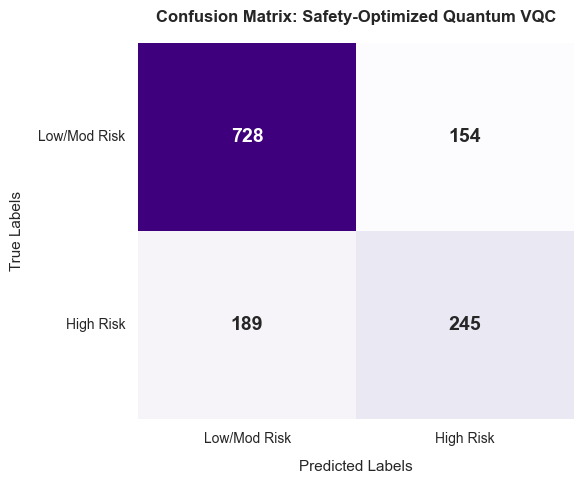

In [19]:
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score

# ---------------------------------------------------------
# 1. Load and Preprocess Data (No SMOTE)
# ---------------------------------------------------------
print("Preparing dataset for Cost-Sensitive PennyLane...")
df = pd.read_csv('modified-shuffled.csv')

features_to_use = [
    'wave_height', 'wave_period', 'wave_direction', 
    'precipitation', 'wind_speed', 'tidal_height_m'
]
X = df[features_to_use].values
y = df['erosion_risk'].apply(lambda x: 1 if x == 'High' else 0).values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dimensionality Reduction
num_qubits = 4
pca = PCA(n_components=num_qubits)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Scale strictly to [-pi, pi] for angle embedding
q_scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_final = pnp.array(q_scaler.fit_transform(X_train_pca), requires_grad=False)
X_test_final = pnp.array(q_scaler.transform(X_test_pca), requires_grad=False)

# PennyLane targets: -1 for Low/Mod, 1 for High Risk
y_train_final = pnp.array(np.where(y_train == 0, -1, 1), requires_grad=False)
y_test_final = np.where(y_test == 0, -1, 1)

# Calculate class weight ratio to penalize missed high risk days
num_low_mod = np.sum(y_train == 0)
num_high = np.sum(y_train == 1)
high_risk_weight = num_low_mod / num_high
print(f"Safety Multiplier for High Risk Class: {high_risk_weight:.4f}")

# ---------------------------------------------------------
# 2. Quantum Architecture Definition
# ---------------------------------------------------------
dev = qml.device("lightning.qubit", wires=num_qubits)

@qml.qnode(dev)
def quantum_classifier(weights, x):
    qml.AngleEmbedding(x, wires=range(num_qubits), rotation='X')
    qml.StronglyEntanglingLayers(weights, wires=range(num_qubits))
    return qml.expval(qml.PauliZ(0))

# ---------------------------------------------------------
# 3. Model Logic & Cost-Sensitive Optimization
# ---------------------------------------------------------
num_layers = 4
weight_shape = (num_layers, num_qubits, 3)
weights = pnp.random.uniform(low=-np.pi, high=np.pi, size=weight_shape, requires_grad=True)

# --- CRITICAL SAFETY FIX: Cost-Sensitive Loss Function ---
def safety_loss_func(weights, X_batch, y_batch):
    loss = 0.0
    for x, y_true in zip(X_batch, y_batch):
        pred = quantum_classifier(weights, x)
        base_error = (pred - y_true) ** 2
        
        # If the true state is High Risk (1), multiply the error penalty
        # This forces the quantum gradient to shift boundaries in favor of high risk recall
        weight_factor = pnp.where(y_true == 1, high_risk_weight, 1.0)
        loss += weight_factor * base_error
        
    return loss / len(X_batch)

# Optimization Hyperparameters
opt = qml.AdamOptimizer(stepsize=0.01)
batch_size = 64
epochs = 10

print("\nStarting Quantum Training with Safety-Weighted Cost Function...")
for epoch in range(epochs):
    permutation = np.random.permutation(len(X_train_final))
    X_shuffled = X_train_final[permutation]
    y_shuffled = y_train_final[permutation]
    
    for i in range(0, len(X_train_final), batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]
        
        weights, cost = opt.step_and_cost(lambda w: safety_loss_func(w, X_batch, y_batch), weights)
        
    train_preds = [np.sign(quantum_classifier(weights, x)) for x in X_train_final[:200]]
    train_acc = accuracy_score(y_train_final[:200], train_preds)
    print(f"Epoch {epoch+1:02d} | Safety Loss: {cost:.4f} | Est. Train Acc: {train_acc:.2f}")

# ---------------------------------------------------------
# 4. Final Evaluation
# ---------------------------------------------------------
print("\nEvaluating on Test Dataset...")
raw_preds = [quantum_classifier(weights, x) for x in X_test_final]
y_pred = np.sign(raw_preds)

print("\n================ SAFETY-OPTIMIZED PENNYLANE EVALUATION ================")
print(classification_report(y_test_final, y_pred, target_names=['Low/Mod Risk', 'High Risk']))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# 5. Generate and Plot Confusion Matrix for Quantum Model
# ---------------------------------------------------------
# Compute the 2x2 confusion matrix array
# Note: y_test_final and y_pred contain -1 and 1 values
cm_quantum = confusion_matrix(y_test_final, y_pred, labels=[-1, 1])

# Set up the plotting environment
plt.figure(figsize=(6, 5))
sns.set_theme(style="white")

# Plot using a seaborn heatmap
sns.heatmap(
    cm_quantum, 
    annot=True, 
    fmt='d', 
    cmap='Purples',  # Using Purples to visually distinguish it from the XGBoost matrix
    cbar=False,
    xticklabels=['Low/Mod Risk', 'High Risk'], 
    yticklabels=['Low/Mod Risk', 'High Risk'],
    annot_kws={"size": 14, "weight": "bold"}
)

# Formatting labels and titles
plt.title('Confusion Matrix: Safety-Optimized Quantum VQC', fontsize=12, pad=15, weight='bold')
plt.xlabel('Predicted Labels', fontsize=11, labelpad=10)
plt.ylabel('True Labels', fontsize=11, labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()

# Save the matrix image for your report/presentation
plt.savefig('quantum_confusion_matrix.png', dpi=300)
print("\nConfusion matrix visualization saved successfully as 'quantum_confusion_matrix.png'!")

# Display the plot
plt.show()

# Hybrid Approach

Preparing dataset for Hybrid Ensemble...

[1/2] Training Classical Baseline (XGBoost)...

[2/2] Training Quantum Baseline (VQC)...
Quantum Training Complete!

Running Ensemble Hybrid Evaluations...

================ HYBRID ENSEMBLE EVALUATION ================
              precision    recall  f1-score   support

Low/Mod Risk       0.82      0.87      0.84       882
   High Risk       0.70      0.62      0.65       434

    accuracy                           0.79      1316
   macro avg       0.76      0.74      0.75      1316
weighted avg       0.78      0.79      0.78      1316



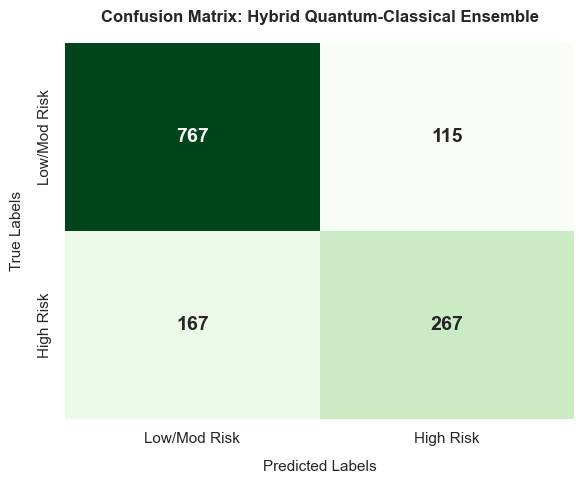

In [16]:
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Load and Preprocess Data (No SMOTE, No Data Leakage)
# ---------------------------------------------------------
print("Preparing dataset for Hybrid Ensemble...")
df = pd.read_csv('modified-shuffled.csv')

features_to_use = [
    'wave_height', 'wave_period', 'wave_direction', 
    'precipitation', 'wind_speed', 'tidal_height_m'
]
X = df[features_to_use].values
y = df['erosion_risk'].apply(lambda x: 1 if x == 'High' else 0).values

# Train/Test Split (Shared identical splits for fairness)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Quantum Pipeline Preprocessing ---
num_qubits = 4
pca = PCA(n_components=num_qubits)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

q_scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_quantum = pnp.array(q_scaler.fit_transform(X_train_pca), requires_grad=False)
X_test_quantum = pnp.array(q_scaler.transform(X_test_pca), requires_grad=False)

# Target vectors: Quantum uses [-1, 1], Classical uses [0, 1]
y_train_quantum = pnp.array(np.where(y_train == 0, -1, 1), requires_grad=False)
y_test_quantum = np.where(y_test == 0, -1, 1)

# Calculate class balance weight for XGBoost
num_low_mod = np.sum(y_train == 0)
num_high = np.sum(y_train == 1)
imbalance_ratio = num_low_mod / num_high

# ---------------------------------------------------------
# 2. Train Classical Component (XGBoost)
# ---------------------------------------------------------
print("\n[1/2] Training Classical Baseline (XGBoost)...")
xgb_model = xgb.XGBClassifier(
    n_estimators=150, max_depth=5, learning_rate=0.05,
    scale_pos_weight=imbalance_ratio, subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)

# ---------------------------------------------------------
# 3. Train Quantum Component (PennyLane VQC)
# ---------------------------------------------------------
print("\n[2/2] Training Quantum Baseline (VQC)...")
dev = qml.device("lightning.qubit", wires=num_qubits)

@qml.qnode(dev)
def quantum_classifier(weights, x):
    qml.AngleEmbedding(x, wires=range(num_qubits), rotation='X')
    qml.StronglyEntanglingLayers(weights, wires=range(num_qubits))
    return qml.expval(qml.PauliZ(0))

num_layers = 4
weight_shape = (num_layers, num_qubits, 3)
weights = pnp.random.uniform(low=-np.pi, high=np.pi, size=weight_shape, requires_grad=True)

# Custom Cost-Sensitive Loss Function
def safety_loss_func(weights, X_batch, y_batch):
    loss = 0.0
    for x, y_true in zip(X_batch, y_batch):
        pred = quantum_classifier(weights, x)
        base_error = (pred - y_true) ** 2
        weight_factor = pnp.where(y_true == 1, imbalance_ratio, 1.0)
        loss += weight_factor * base_error
    return loss / len(X_batch)

opt = qml.AdamOptimizer(stepsize=0.01)
batch_size = 64
epochs = 10

for epoch in range(epochs):
    permutation = np.random.permutation(len(X_train_quantum))
    X_shuffled = X_train_quantum[permutation]
    y_shuffled = y_train_quantum[permutation]
    
    for i in range(0, len(X_train_quantum), batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]
        weights, cost = opt.step_and_cost(lambda w: safety_loss_func(w, X_batch, y_batch), weights)

print("Quantum Training Complete!")

# ---------------------------------------------------------
# 4. Generate Predictions & Run Parallel Voting Ensemble
# ---------------------------------------------------------
print("\nRunning Ensemble Hybrid Evaluations...")

# A. Classical Probabilities (Probability of class 1)
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

# B. Quantum Probabilities
# The expectation output lands in [-1, 1]. We map it to a [0, 1] probability interval via MinMax scaling
raw_quantum_preds = np.array([quantum_classifier(weights, x) for x in X_test_quantum])
quantum_probs = (raw_quantum_preds - raw_quantum_preds.min()) / (raw_quantum_preds.max() - raw_quantum_preds.min())

# C. Ensemble Voting Fusion
# You can weight alpha based on who you trust more. 0.5 means a completely equal hybrid vote.
alpha = 0.5 
hybrid_probs = (alpha * xgb_probs) + ((1 - alpha) * quantum_probs)

# Classify threshold based on safety profile (0.5 is standard, lower it slightly if you want extreme high risk recall)
hybrid_predictions = np.where(hybrid_probs >= 0.5, 1, 0)

# ---------------------------------------------------------
# 5. Hybrid Metrics & Visualization
# ---------------------------------------------------------
print("\n================ HYBRID ENSEMBLE EVALUATION ================")
print(classification_report(y_test, hybrid_predictions, target_names=['Low/Mod Risk', 'High Risk']))

# Generate 2x2 Hybrid Confusion Matrix
cm_hybrid = confusion_matrix(y_test, hybrid_predictions)

plt.figure(figsize=(6, 5))
sns.set_theme(style="white")
sns.heatmap(
    cm_hybrid, annot=True, fmt='d', cmap='Greens', cbar=False,
    xticklabels=['Low/Mod Risk', 'High Risk'], 
    yticklabels=['Low/Mod Risk', 'High Risk'],
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title('Confusion Matrix: Hybrid Quantum-Classical Ensemble', fontsize=12, pad=15, weight='bold')
plt.xlabel('Predicted Labels', fontsize=11, labelpad=10)
plt.ylabel('True Labels', fontsize=11, labelpad=10)
plt.tight_layout()
plt.savefig('hybrid_ensemble_confusion_matrix.png', dpi=300)
plt.show()

# Visualization

Comparison graph successfully generated and saved as 'model_performance_comparison.png'!


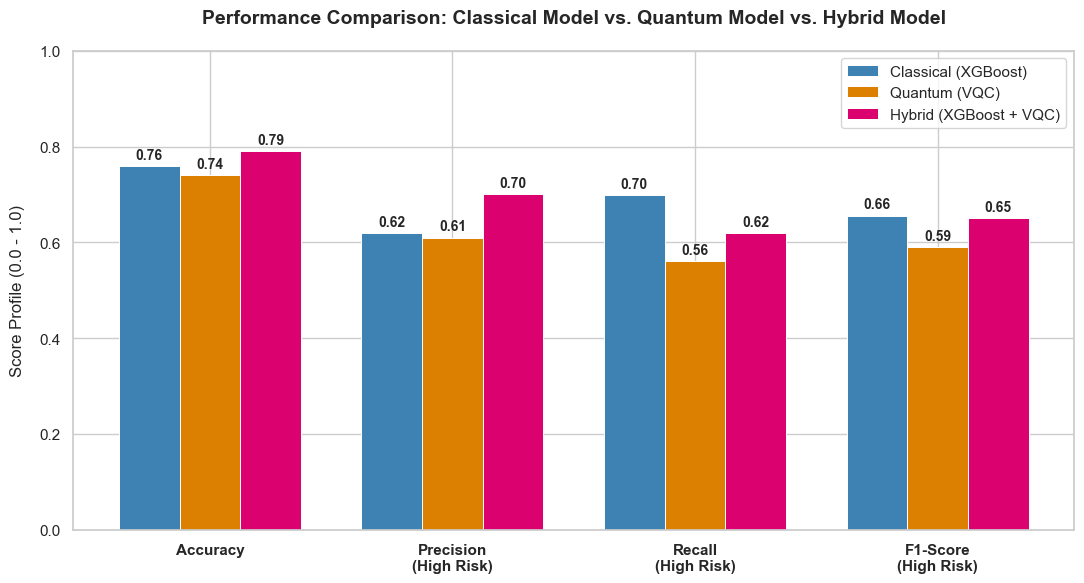

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ---------------------------------------------------------
# Data Setup from Your Realized Model Outputs
# ---------------------------------------------------------
metrics = ['Accuracy', 'Precision\n(High Risk)', 'Recall\n(High Risk)', 'F1-Score\n(High Risk)']

# Extracted exact values from your model output reports
hybrid_scores = [0.7900, 0.7000, 0.6200, 0.6500]
quantum_scores = [0.7400, 0.6100, 0.5600, 0.5900]
xgboost_scores = [0.7584, 0.6184, 0.6982, 0.6558]

x = np.arange(len(metrics))  # Label locations
width = 0.25  # Width of the bars

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))

# Plot bars with distinctive colors
rects1 = ax.bar(x - width, xgboost_scores, width, label='Classical (XGBoost)', color="#3e82b4", linewidth=0.7)
rects2 = ax.bar(x, quantum_scores, width, label='Quantum (VQC)', color="#db8001", linewidth=0.7)
rects3 = ax.bar(x + width, hybrid_scores, width, label='Hybrid (XGBoost + VQC)', color="#db016e", linewidth=0.7)

# ---------------------------------------------------------
# Formatting and Aesthetics
# ---------------------------------------------------------
ax.set_title('Performance Comparison: Classical Model vs. Quantum Model vs. Hybrid Model', fontsize=14, pad=20, weight='bold')
ax.set_ylabel('Score Profile (0.0 - 1.0)', fontsize=12, labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11, weight='bold')
ax.set_ylim(0, 1.0)  # Set limit to standard classification range
ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=False)

# Helper function to auto-attach value labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, weight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()

# Save image for your project report
plt.savefig('model_performance_comparison.png', dpi=300)
print("Comparison graph successfully generated and saved as 'model_performance_comparison.png'!")

# Display chart inline
plt.show()